问题：如果使用了全连接层，可能会完全放弃表征的空间结构。

网络中的网络（NiN）提供了一个非常简单的解决方案：在每个像素的通道上分别使用多层感知机

NIN块

全连接层的输入和输出通常是分别对应于样本和特征的二维张量。 NiN的想法是在每个像素位置（针对每个高度和宽度）应用一个全连接层。

将权重连接到每个空间位置，我们可以将其视为1×1卷积层，或作为在每个像素位置上独立作用的全连接层。

NiN块以一个普通卷积层开始，后面是两个 1×1 的卷积层。这两个 1×1 卷积层充当带有ReLU激活函数的逐像素全连接层。

In [1]:
import torch
from torch import nn


def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU())

NiN模型

NiN使用窗口形状为11×11、5×5和3×3的卷积层，输出通道数量与AlexNet中的相同。每个NiN块后有一个最大汇聚层，汇聚窗口形状为3×3，步幅为2。
NiN和AlexNet之间的一个显著区别是NiN完全取消了全连接层。

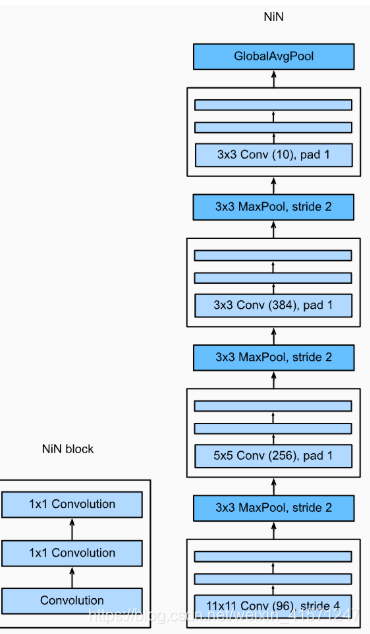

In [2]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())

查看每个块的输出形状

In [3]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


训练模型

In [6]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time

# 超参数
lr, num_epochs, batch_size = 0.1, 10, 128

# 选择设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("training on", device)

# 数据预处理
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 下载数据集
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

# 数据加载器
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 计算准确率
def evaluate_accuracy_gpu(net, data_iter, device):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += y.numel()
    return correct / total

# 参数初始化
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

net.apply(init_weights)

# 训练函数
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):

    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        net.train()
        metric_loss = 0.0
        metric_correct = 0
        metric_total = 0
        start = time.time()

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()

            metric_loss += l.item() * X.shape[0]
            metric_correct += (y_hat.argmax(dim=1) == y).sum().item()
            metric_total += y.numel()

        train_loss = metric_loss / metric_total
        train_acc = metric_correct / metric_total
        test_acc = evaluate_accuracy_gpu(net, test_iter, device)

        print(f"epoch {epoch + 1}, "
              f"train loss {train_loss:.4f}, "
              f"train acc {train_acc:.4f}, "
              f"test acc {test_acc:.4f}, "
              f"time {time.time() - start:.1f} sec")

# 开始训练
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda
epoch 1, train loss 1.8613, train acc 0.3152, test acc 0.6708, time 12.8 sec
epoch 2, train loss 0.7547, train acc 0.7255, test acc 0.7900, time 13.0 sec
epoch 3, train loss 0.5336, train acc 0.8035, test acc 0.8347, time 13.3 sec
epoch 4, train loss 0.4472, train acc 0.8348, test acc 0.8131, time 13.2 sec
epoch 5, train loss 0.3992, train acc 0.8537, test acc 0.8485, time 12.9 sec
epoch 6, train loss 0.3555, train acc 0.8700, test acc 0.8738, time 12.9 sec
epoch 7, train loss 0.3286, train acc 0.8800, test acc 0.8785, time 13.3 sec
epoch 8, train loss 0.3028, train acc 0.8891, test acc 0.8908, time 13.3 sec
epoch 9, train loss 0.2837, train acc 0.8961, test acc 0.8971, time 13.0 sec
epoch 10, train loss 0.2719, train acc 0.8993, test acc 0.8940, time 13.0 sec


## 练习

1. 调整NiN的超参数，以提高分类准确性。


增加训练轮数

In [10]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())
net.apply(init_weights)

lr, num_epochs, batch_size = 0.1, 20, 128

train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 1.9801, train acc 0.2781, test acc 0.5214, time 13.4 sec
epoch 2, train loss 1.2270, train acc 0.5439, test acc 0.5652, time 13.1 sec
epoch 3, train loss 1.1150, train acc 0.5796, test acc 0.5798, time 13.2 sec
epoch 4, train loss 1.0592, train acc 0.5985, test acc 0.6097, time 13.6 sec
epoch 5, train loss 1.0187, train acc 0.6120, test acc 0.6167, time 13.4 sec
epoch 6, train loss 0.9868, train acc 0.6210, test acc 0.6187, time 13.0 sec
epoch 7, train loss 0.8646, train acc 0.6701, test acc 0.6877, time 12.9 sec
epoch 8, train loss 0.7697, train acc 0.6931, test acc 0.6798, time 13.1 sec
epoch 9, train loss 0.7391, train acc 0.7027, test acc 0.6957, time 13.3 sec
epoch 10, train loss 0.7433, train acc 0.7004, test acc 0.7006, time 13.3 sec
epoch 11, train loss 0.7086, train acc 0.7118, test acc 0.6992, time 13.0 sec
epoch 12, train loss 0.6903, train acc 0.7181, test acc 0.7113, time 13.5 sec
epoch 13, train loss 0.6780, train acc 0.7238, test acc 0.7102, time 13.0

减少学习率

In [11]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())
net.apply(init_weights)

lr, num_epochs, batch_size = 0.01, 10, 128

train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 2.3015, train acc 0.1532, test acc 0.1820, time 12.8 sec
epoch 2, train loss 2.2928, train acc 0.2121, test acc 0.2359, time 12.8 sec
epoch 3, train loss 2.1572, train acc 0.2416, test acc 0.3751, time 12.7 sec
epoch 4, train loss 1.5456, train acc 0.4495, test acc 0.5361, time 12.8 sec
epoch 5, train loss 1.1762, train acc 0.5653, test acc 0.6688, time 12.7 sec
epoch 6, train loss 0.7632, train acc 0.7227, test acc 0.7585, time 13.0 sec
epoch 7, train loss 0.6465, train acc 0.7597, test acc 0.7558, time 13.3 sec
epoch 8, train loss 0.5854, train acc 0.7805, test acc 0.7839, time 13.2 sec
epoch 9, train loss 0.5441, train acc 0.7970, test acc 0.8062, time 13.2 sec
epoch 10, train loss 0.5146, train acc 0.8078, test acc 0.7973, time 13.1 sec


我通过调整学习率和训练轮数来提高分类准确率。实验中发现，学习率对结果影响最大。原始的lr=0.1容易导致训练不稳定，而将学习率调小到0.01后，模型收敛更平稳。与此同时，将训练轮数从10增加到20，有助于模型进一步学习特征。

1. 为什么NiN块中有两个$1\times 1$卷积层？删除其中一个，然后观察和分析实验现象。

In [12]:
def nin_block_reduced(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU()
    )

In [13]:
def get_reduced_net():
    return nn.Sequential(
        nin_block_reduced(1, 96, kernel_size=11, strides=4, padding=0),
        nn.MaxPool2d(3, stride=2),
        nin_block_reduced(96, 256, kernel_size=5, strides=1, padding=2),
        nn.MaxPool2d(3, stride=2),
        nin_block_reduced(256, 384, kernel_size=3, strides=1, padding=1),
        nn.MaxPool2d(3, stride=2),
        nn.Dropout(0.5),
        nin_block_reduced(384, 10, kernel_size=3, strides=1, padding=1),
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten()
    )

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr, num_epochs = 1e-3, 10

net_reduced = get_reduced_net()
net_reduced.apply(init_weights)
train_ch6(net_reduced, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 2.3025, train acc 0.1120, test acc 0.1877, time 12.6 sec
epoch 2, train loss 2.3020, train acc 0.1344, test acc 0.1770, time 12.6 sec
epoch 3, train loss 2.3013, train acc 0.1519, test acc 0.1828, time 12.9 sec
epoch 4, train loss 2.3003, train acc 0.1750, test acc 0.2047, time 12.8 sec
epoch 5, train loss 2.2991, train acc 0.1930, test acc 0.2740, time 12.6 sec
epoch 6, train loss 2.2973, train acc 0.2106, test acc 0.2799, time 12.6 sec
epoch 7, train loss 2.2950, train acc 0.2218, test acc 0.2810, time 12.5 sec
epoch 8, train loss 2.2916, train acc 0.2349, test acc 0.2825, time 13.0 sec
epoch 9, train loss 2.2864, train acc 0.2472, test acc 0.2726, time 12.9 sec
epoch 10, train loss 2.2786, train acc 0.2579, test acc 0.2736, time 12.7 sec


删除1*1卷积之后，效果变差

NiN块中设置两个1×1卷积层，主要是为了增强通道之间的非线性组合能力。普通卷积层负责提取局部空间特征，而后续的1×1卷积层相当于在每个空间位置上构建一个小型多层感知机，对通道信息进行进一步变换和抽象。删除其中一个1×1卷积层后，模型结构变浅，参数量减少，训练速度可能略有提升，但网络的表达能力也会下降。

1. 一次性直接将$384 \times 5 \times 5$的表示缩减为$10 \times 5 \times 5$的表示，会存在哪些问题？

In [16]:
def get_bad_net():
    net = nn.Sequential(
        nin_block(1, 96, kernel_size=11, strides=4, padding=0),
        nn.MaxPool2d(3, stride=2),

        nin_block(96, 256, kernel_size=5, strides=1, padding=2),
        nn.MaxPool2d(3, stride=2),

        nin_block(256, 384, kernel_size=3, strides=1, padding=1),
        nn.MaxPool2d(3, stride=2),

        nn.Dropout(0.5),

        # ❗直接从 384 → 10
        nn.Conv2d(384, 10, kernel_size=1),

        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten()
    )
    return net

net = get_bad_net()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr, num_epochs = 1e-3, 10

net.apply(init_weights)
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 2.3002, train acc 0.1275, test acc 0.1005, time 13.5 sec
epoch 2, train loss 2.2964, train acc 0.1834, test acc 0.1946, time 13.2 sec
epoch 3, train loss 2.2914, train acc 0.2333, test acc 0.3990, time 13.1 sec
epoch 4, train loss 2.2837, train acc 0.2790, test acc 0.4822, time 13.0 sec
epoch 5, train loss 2.2693, train acc 0.3179, test acc 0.4983, time 13.9 sec
epoch 6, train loss 2.2363, train acc 0.3460, test acc 0.5044, time 13.0 sec
epoch 7, train loss 2.1240, train acc 0.3807, test acc 0.5165, time 13.2 sec
epoch 8, train loss 1.7114, train acc 0.4469, test acc 0.6342, time 13.5 sec
epoch 9, train loss 1.2394, train acc 0.5632, test acc 0.6881, time 13.2 sec
epoch 10, train loss 1.0103, train acc 0.6382, test acc 0.7139, time 13.0 sec


如果将特征表示从 $384 \times 5 \times 5$ 直接压缩到 $10 \times 5 \times 5$，会导致信息压缩过于激进。由于中间缺少逐步的特征变换过程，模型无法充分学习高维特征之间的复杂关系。

此外，直接使用一次 $1\times1$ 卷积相当于仅进行一次线性映射，非线性表达能力不足，从而降低模型的表示能力。